Perform QA/QC on level 1 meteo data and store as level 2 .parquet files.

Aggregate level 2 data and store as .parquet files.

[TODO] A lot ... Generate submission-ready files.

In [ ]:
import os
# import matplotlib as plt
%matplotlib ipympl
import polars as pl

from processing.meteo import Meteo
met = Meteo()

statistic,iii,zzzztttt,tre200s0,uor200s0,prestas0,fa1010z0,da1010z0,rre150z0,ta1200s0,ua1200s0,pa1stas0,fkl010z0,dkl010z0,ra1150z0,fkl010z1,gor000z0,ta2200s0,ua2200s0,source,dtm
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""","""24749""","""24749""",23772.0,23772.0,23772.0,23772.0,23772.0,23772.0,24613.0,24613.0,24613.0,24613.0,24613.0,24613.0,24638.0,24585.0,24355.0,24355.0,"""24749""","""24749"""
"""null_count""","""0""","""0""",977.0,977.0,977.0,977.0,977.0,977.0,136.0,136.0,136.0,136.0,136.0,136.0,111.0,164.0,394.0,394.0,"""0""","""0"""
"""mean""",null,null,6.612292,77.902574,654.906335,4.229091,148.24689,0.159751,6.563162,76.563406,660.500414,4.3341,149.125357,0.021732,6.659148,169.852512,6.472897,78.411276,null,"""2022-07-25 15:…"
"""std""",null,null,10.839987,48.543898,60.893481,16.52767,98.552393,2.488587,1.415537,19.330292,12.657612,2.926286,97.859684,0.278677,5.402893,273.388361,2.401685,20.75711,null,null
"""min""","""187""","""202201010000""",-3.2,0.0,0.0,-1.5,-2.0,0.0,1.8,9.9,0.0,0.0,0.0,0.0,0.0,0.0,0.2,9.76,"""/product_data/…","""2022-01-01 00:…"
"""25%""",null,null,4.8,64.2,660.0,1.7,89.1,0.0,5.5,65.1,660.0,2.0,86.2,0.0,3.9,0.0,4.74,65.58,null,"""2022-04-15 02:…"
"""50%""",null,null,6.1,79.2,660.8,2.7,114.6,0.0,6.4,80.2,660.8,4.0,133.2,0.0,6.3,2.9,6.12,84.11,null,"""2022-07-31 03:…"
"""75%""",null,null,7.9,88.5,661.5,4.2,236.3,0.0,7.4,91.9,661.5,6.4,223.1,0.0,8.9,240.7,7.86,97.45,null,"""2022-11-17 11:…"
"""max""","""187""","""202212312350""",1058.9,1063.5,941.0,349.1,1800.0,60.0,13.4,659.0,664.1,73.9,360.0,20.51,660.9,1534.3,16.14,99.36,"""/product_data/…","""2022-12-31 23:…"


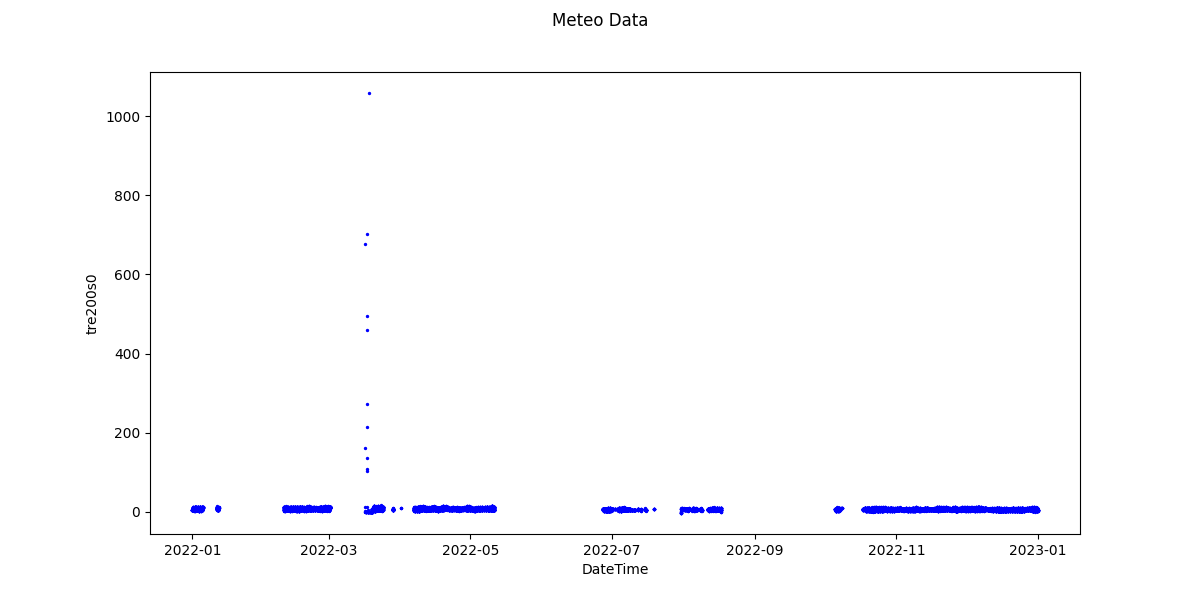

OrderedDict([('iii', String),
             ('zzzztttt', String),
             ('tre200s0', Float64),
             ('uor200s0', Float64),
             ('prestas0', Float64),
             ('fa1010z0', Float64),
             ('da1010z0', Float64),
             ('rre150z0', Float64),
             ('ta1200s0', Float64),
             ('ua1200s0', Float64),
             ('pa1stas0', Float64),
             ('fkl010z0', Float64),
             ('dkl010z0', Float64),
             ('ra1150z0', Float64),
             ('fkl010z1', Float64),
             ('gor000z0', Float64),
             ('ta2200s0', Float64),
             ('ua2200s0', Float64),
             ('source', String),
             ('dtm', Datetime(time_unit='us', time_zone=None))])

In [28]:
# quick'n'dirty plot of one variable
source = os.path.join(os.getcwd(), "data/level1/2022/vrxa00.parquet")
df = pl.read_parquet(source)
display(df.describe())

variable = "ta2200s0"
variable = "fkl010z0"
variable = "fa1010z0"
variable = "fkl010z1"
variable = "tre200s0"
met.plot_data(df, variable=variable)
# df_clean, errors = met.remove_extremes(df, variable=variable, q=0.001)
# met.plot_data(df_clean, variable=variable)
df.schema

In [45]:
df.filter(pl.col(variable).is_not_null()).describe()

statistic,iii,zzzztttt,tre200s0,uor200s0,prestas0,fa1010z0,da1010z0,rre150z0,ta1200s0,ua1200s0,pa1stas0,fkl010z0,dkl010z0,ra1150z0,fkl010z1,gor000z0,ta2200s0,ua2200s0,source,dtm
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""","""23772""","""23772""",23772.0,23772.0,23772.0,23772.0,23772.0,23772.0,23714.0,23714.0,23714.0,23714.0,23714.0,23714.0,23728.0,23657.0,23383.0,23383.0,"""23772""","""23772"""
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,58.0,58.0,58.0,58.0,58.0,58.0,44.0,115.0,389.0,389.0,"""0""","""0"""
"""mean""",null,null,6.612292,77.902574,654.906335,4.229091,148.24689,0.159751,6.553099,76.617753,660.524095,4.390343,152.448233,0.021443,6.616099,169.475428,6.463226,78.533314,null,"""2022-07-27 19:…"
"""std""",null,null,10.839987,48.543898,60.893481,16.52767,98.552393,2.488587,1.406829,18.748526,12.178421,2.846013,96.74305,0.277762,3.437202,272.236148,2.384436,20.48259,null,null
"""min""","""187""","""202201010000""",-3.2,0.0,0.0,-1.5,-2.0,0.0,2.3,12.6,0.0,0.0,0.0,0.0,0.0,0.0,0.2,9.76,"""/product_data/…","""2022-01-01 00:…"
"""25%""",null,null,4.8,64.2,660.0,1.7,89.1,0.0,5.5,65.3,660.0,2.1,92.6,0.0,3.9,0.0,4.74,65.97,null,"""2022-04-15 20:…"
"""50%""",null,null,6.1,79.2,660.8,2.7,114.6,0.0,6.3,80.1,660.8,4.0,134.4,0.0,6.3,2.7,6.13,84.05,null,"""2022-07-31 01:…"
"""75%""",null,null,7.9,88.5,661.5,4.2,236.3,0.0,7.4,91.7,661.5,6.4,227.6,0.0,8.9,241.0,7.86,97.18,null,"""2022-11-19 03:…"
"""max""","""187""","""202212312350""",1058.9,1063.5,941.0,349.1,1800.0,60.0,13.4,100.0,664.1,17.1,360.0,20.51,60.0,1534.3,16.14,99.36,"""/product_data/…","""2022-12-31 23:…"


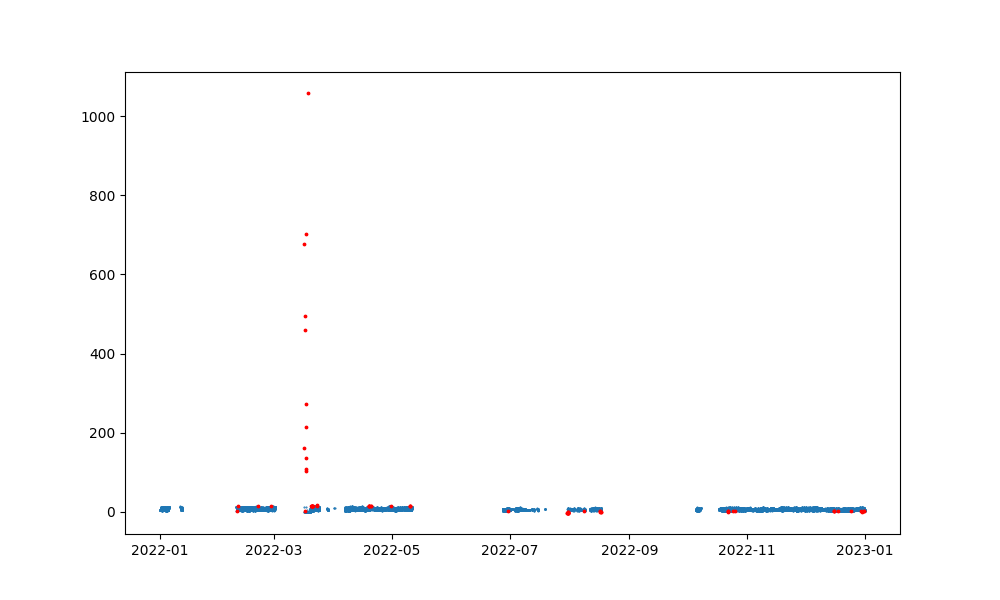

In [98]:
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

data = df.filter(pl.col(variable).is_not_null())

# Use the Sub-LOF method to detect outliers
lof = LocalOutlierFactor(n_neighbors=10, contamination='auto')
outliers = lof.fit_predict(data[variable].to_numpy().reshape((-1, 1)))
data = data.with_columns(pl.lit(outliers).alias("outliers"))
data.describe()
plt.figure(figsize=(10, 6))
plt.scatter(data["dtm"], data[variable], marker=".", s=1, label=variable)
plt.scatter(data["dtm"].filter(data["outliers"] == -1), data[variable].filter(data["outliers"] == -1), color='red', s=3, label="Outliers")
